In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.2 MB/s eta 0:00:00


In [3]:
from pathlib import Path

import joblib
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import mixed_precision
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential

In [4]:
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

In [5]:
# TOP_STOCKS = ["NVDA", "AAPL", "MSFT", "AMZN", "GOOGL", "GOOG", "META", "AVGO", "TSLA", "ASML"]
STOCKS = ['AAPL', 'TSLA', 'MSFT']
OUTPUT_PATH = Path("/content/drive/MyDrive/Data Science projects/stock_market_prediction/outputs")

df_adjclose = pd.read_csv(OUTPUT_PATH /'adjclose_final_data.csv')
train_data = joblib.load(OUTPUT_PATH /'train_data.joblib')
test_data = joblib.load(OUTPUT_PATH /'test_data.joblib')

In [6]:
def create_sequences(data, seq_length):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length, 0])
        y.append(data[i+seq_length, 0])
    return np.array(x), np.array(y)

In [7]:
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(hp.Int('seq_length', min_value=30, max_value=120, step=30), 1)))
    model.add(LSTM(units=hp.Int('units_1', min_value=32, max_value=128, step=32), return_sequences=True))
    model.add(Dropout(rate=hp.Float('dropout_1', 0.1, 0.5, step=0.1)))
    model.add(LSTM(units=hp.Int('units_2', min_value=32, max_value=128, step=32), return_sequences=False))
    model.add(Dropout(rate=hp.Float('dropout_2', 0.1, 0.5, step=0.1)))
    model.add(Dense(units=hp.Int('dense_units', 16, 64, step=16)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

In [8]:
model_lstm = {}
default_seq_length = 60
EPOCHS = 50
BATCH_SIZE = 32
split_value = int(0.9 * len(df_adjclose))
split = split_value - default_seq_length

callbacks = [EarlyStopping(monitor='val_loss', patience=5), ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=1)]

In [9]:
for stock in STOCKS:
    print(f"\n--- Training Tuned LSTM for {stock} ---")

    # Scale data: fit only on training data, transform both train and test
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_data[stock].values.reshape(-1, 1))
    test_scaled = scaler.transform(test_data[stock].values.reshape(-1, 1))

    # Create sequences for initial tuner search using default_seq_length
    X_train_initial, y_train_initial = create_sequences(train_scaled, default_seq_length)

    # Reshape for Keras [samples, time steps, features]
    X_train_initial = X_train_initial.reshape(X_train_initial.shape[0], X_train_initial.shape[1], 1)

    tuner = kt.RandomSearch(
        build_model,
        objective='val_loss',
        max_trials=5,
        executions_per_trial=1,
        directory= OUTPUT_PATH / 'models/lstm/lstm_tuner',
        project_name=f'lstm_{stock}',
        overwrite=True
    )

    tuner.search(
        X_train_initial, y_train_initial,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=callbacks,
        verbose=2
    )

    best_hp = tuner.get_best_hyperparameters(1)[0]
    best_seq_length = best_hp.get('seq_length')
    print(f"Best sequence length for {stock}: {best_seq_length}")

    # Re-create sequences with the best_seq_length for final model training and evaluation
    X_train_final, y_train_final = create_sequences(train_scaled, best_seq_length)
    X_test_final, y_test_final = create_sequences(test_scaled, best_seq_length)

    # Reshape for Keras [samples, time steps, features]
    X_train_final = X_train_final.reshape(X_train_final.shape[0], X_train_final.shape[1], 1)
    X_test_final = X_test_final.reshape(X_test_final.shape[0], X_test_final.shape[1], 1)

    model = tuner.hypermodel.build(best_hp)
    history = model.fit(
        X_train_final, y_train_final,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=callbacks,
        verbose=2
    )

    # Predictions
    y_pred_scaled = model.predict(X_test_final)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_actual = scaler.inverse_transform(y_test_final.reshape(-1, 1))

    # Metrics
    mae = mean_absolute_error(y_test_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

    # Store results using the globally defined 'model_lstm' dictionary
    model_lstm[stock] = {
        "model_object": model,
        "scaler": scaler,
        "y_test": y_test_actual.flatten(),
        "y_pred": y_pred.flatten(),
        "y_test_index": test_data[stock].index[-len(y_test_actual):],
        "history": history,
        "metrics": {
            "mae": round(mae, 4),
            "rmse": round(rmse, 4),
        }
    }
    print(f"Finished {stock}: MAE = {mae:.4f}")

Trial 5 Complete [00h 00m 20s]
val_loss: 0.0065964702516794205

Best val_loss So Far: 0.0065964702516794205
Total elapsed time: 00h 01m 37s
Best sequence length for MSFT: 90
Epoch 1/50
95/95 - 3s - 34ms/step - loss: 0.0355 - mae: 0.1058 - val_loss: 0.0151 - val_mae: 0.0964 - learning_rate: 1.0000e-03
Epoch 2/50
95/95 - 1s - 10ms/step - loss: 0.0061 - mae: 0.0525 - val_loss: 0.0118 - val_mae: 0.0919 - learning_rate: 1.0000e-03
Epoch 3/50
95/95 - 1s - 10ms/step - loss: 0.0053 - mae: 0.0499 - val_loss: 0.0104 - val_mae: 0.0860 - learning_rate: 1.0000e-03
Epoch 4/50
95/95 - 1s - 10ms/step - loss: 0.0054 - mae: 0.0503 - val_loss: 0.0085 - val_mae: 0.0773 - learning_rate: 1.0000e-03
Epoch 5/50
95/95 - 1s - 12ms/step - loss: 0.0056 - mae: 0.0512 - val_loss: 0.0079 - val_mae: 0.0740 - learning_rate: 1.0000e-03
Epoch 6/50
95/95 - 1s - 15ms/step - loss: 0.0049 - mae: 0.0467 - val_loss: 0.0079 - val_mae: 0.0714 - learning_rate: 1.0000e-03
Epoch 7/50
95/95 - 2s - 22ms/step - loss: 0.0049 - mae: 0.

AAPL(LSTM): MAE: 7.397, RMSE: 8.7721


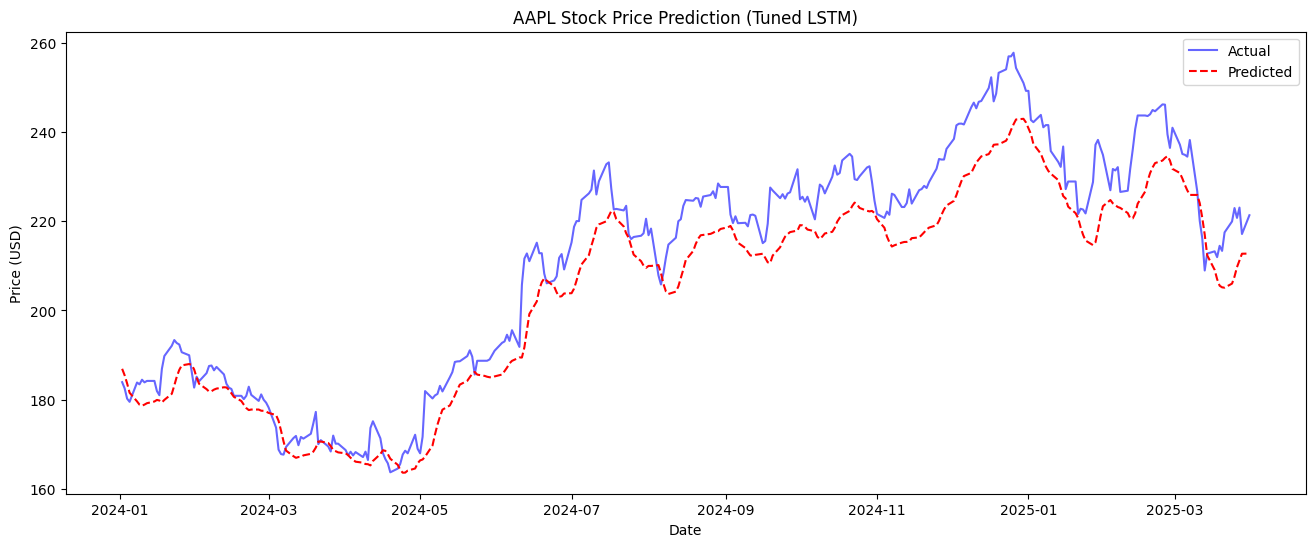

TSLA(LSTM): MAE: 9.663, RMSE: 13.9846


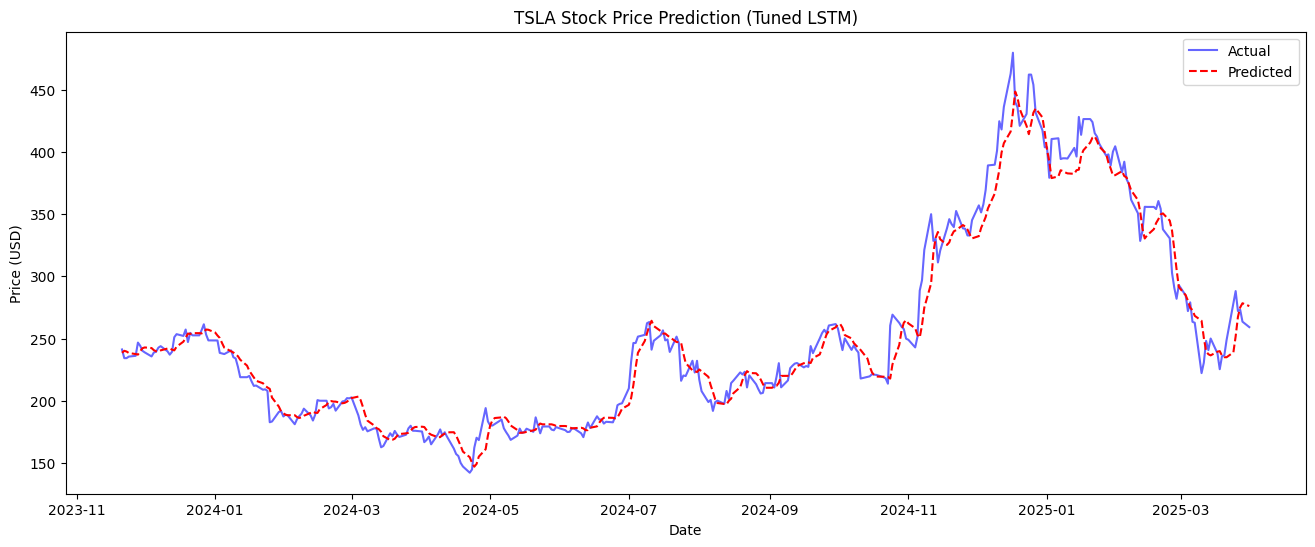

MSFT(LSTM): MAE: 15.3394, RMSE: 17.2368


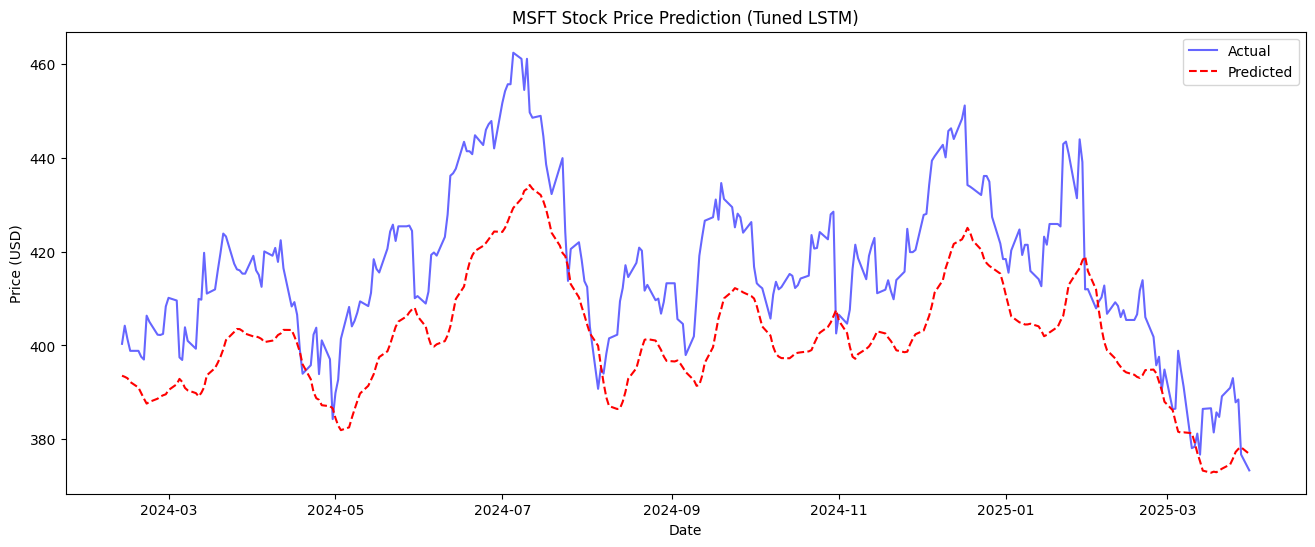

In [10]:
# Plotting
for stock in STOCKS:
    print(f"{stock}(LSTM): MAE: {model_lstm[stock]['metrics']['mae']}, RMSE: {model_lstm[stock]['metrics']['rmse']}")
    plt.figure(figsize=(16, 6))
    plt.plot(model_lstm[stock]['y_test_index'], model_lstm[stock]['y_test'], label='Actual', color='blue', alpha=0.6)
    plt.plot(model_lstm[stock]['y_test_index'], model_lstm[stock]['y_pred'], label='Predicted', color='red', linestyle='--')
    plt.title(f'{stock} Stock Price Prediction (Tuned LSTM)')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.show()

In [11]:
# Save results
joblib.dump(model_lstm, OUTPUT_PATH / 'models/model_lstm.joblib')

for stock in STOCKS:
  model = model_lstm[stock]['model_object']
  model.save(OUTPUT_PATH / f"models/lstm/model_lstm_{stock}.keras")
  model.save(OUTPUT_PATH / f"models/lstm/model_lstm_{stock}.h5")

joblib.dump(scaler, OUTPUT_PATH / "models/lstm/scaler_lstm.pkl")

['/content/drive/MyDrive/Data Science projects/stock_market_prediction/outputs/models/lstm/scaler_lstm.pkl']